(02-09-black-scholes)=

# Black-Scholes-Merton en de CBOE

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1961–1973.

**Wat we al weten.** In [](#01-02-bachelier) leidde Bachelier de eerste
optieformule af door een verwachting te nemen, zonder te kunnen zeggen waarom juist
die verwachting de prijs is. Osborne en Samuelson verplaatsten de Brownse beweging
naar de logaritme van de prijs, en het CAPM uit [](#02-08-capm) gaf een prijs van
risico. De barst was praktisch: wie een optie wilde waarderen, moest het verwachte
rendement van het aandeel kennen — het slechtst meetbare getal van de reeks — en
een discontovoet kiezen voor een contract waarvan het risico met elke koersbeweging
verandert.

**Welke vraag staat open.** Kan men een optie prijzen zonder te weten welk
rendement het aandeel verwacht en hoe risicoavers beleggers zijn?
```

## Overzicht

Op 26 april 1973 opende de Chicago Board Options Exchange, de eerste beurs voor
gestandaardiseerde opties. In het mei/juni-nummer van de *Journal of Political
Economy* verscheen *The Pricing of Options and Corporate Liabilities* van Fischer
Black en Myron Scholes {cite}`BlackScholes1973`, en in het voorjaarsnummer van de
*Bell Journal* Robert Mertons *Theory of Rational Option Pricing*
{cite}`Merton1973`. Dit werk definieert het tijdvak omdat het de eerste
waarderingstheorie is zonder voorkeursparameter — geen risicoaversie, geen
verwacht rendement — en daarmee het eerste resultaat dat niet uit evenwicht maar
uit *replicatie* volgt.

De epistemische status verschilt van die van het CAPM (motief 3). Black-Scholes
is een *relatieve* waarderingsregel: zij zegt niet wat een aandeel waard is, alleen
wat een optie waard is *gegeven* het aandeel. Daarom breekt ze ook anders: niet in
het gemiddelde, maar in de tweede momenten — en die zijn goed meetbaar.

We beginnen met een binomiale boom van drie stappen, waarin de werkelijke kans op
een stijging nergens in de prijs voorkomt. De theorie loopt via Itô's lemma naar
de delta-hedge-afleiding van de PDE, de risiconeutrale oplossing, put-call-pariteit,
de Greeks en implied volatility. De simulatie repliceert de hedgefouttabel van
Derman en Kamal {cite}`DermanKamal1999`. De replicatie op echte data bouwt het
implied-volatility-oppervlak van SPY-opties, vindt de *smirk* (een implied volatility die daalt naarmate de uitoefenprijs stijgt) die Rubinstein
{cite}`Rubinstein1994` na 1987 beschreef, en zet de VIX naast de daarna
gerealiseerde volatiliteit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Black vertelde het in 1989 zelf, met een getal {cite}`Black1989`. Stel dat een
call ongeveer vijftig cent stijgt als het aandeel een dollar stijgt, en vijftig
cent daalt als het een dollar daalt. Verkoop twee opties en koop één aandeel: wat
men op het ene verliest, wint men op het andere. Voor kleine bewegingen is die
positie vrijwel zonder risico, en een positie zonder risico hoort de rente op te
leveren — anders leent iedereen om haar op te zetten. "This one principle gives us
the option formula."

Het verrassende zit in wat er *niet* in staat. Nergens is gevraagd of het aandeel
waarschijnlijk stijgt, of hoe bang beleggers voor verlies zijn. De afgedekte positie
heeft geen risico, dus risicoaversie doet er niet toe; en een opwaartse verwachting
zit al in de aandelenkoers en hoeft niet nog eens in de optiekoers. Wat wél telt,
is hoe *hard* het aandeel beweegt: de verhouding van twee opties op één aandeel
geldt maar even en moet steeds worden bijgesteld, en hoe wilder het aandeel, hoe
duurder dat bijstellen. De volatiliteit is de enige grootheid over de toekomst die
de markt moet inschatten.

Dat loste een probleem op dat een decennium had stilgelegen. Sprenkle rekende in
1961 de verwachte waarde van een warrant op expiratie uit onder een lognormaal
aandeel {cite}`Sprenkle1961`, Boness deed in 1964 hetzelfde en disconteerde met het
verwachte rendement van het aandeel {cite}`Boness1964`, en Samuelson gaf het aandeel
in 1965 een verwachte opbrengst $\alpha$ die afhing van "the typical investor's
utility aversion to risk" {cite}`Samuelson1965b`. Alle drie hielden een parameter
over die niemand kon meten. Black: "No single discount rate will do, however,
because the risk of the warrant depends on the stock price and time."

Het verhaal van de ontdekking is kort. Black had in juni 1969 de
differentiaalvergelijking, maar "didn't recognize the equation as a version of the
'heat equation'". Met Scholes vond hij de uitweg: als de waarde niet van het
verwachte rendement afhangt, mag men de rente invullen, en dan is Sprenkles formule
het antwoord. Merton wees erop dat bij continue handel een positie "literally
riskless" is. Het manuscript van oktober 1970 werd door het JPE teruggestuurd als
te gespecialiseerd en door de *Review of Economics and Statistics* zonder
referentenrapport afgewezen; pas na belangstelling van Merton Miller en Eugene Fama
aanvaardde het JPE het in augustus 1971.

```{note}
De CBOE opende met calls op zestien aandelen; die eerste dag werden 911 contracten
verhandeld, en puts kwamen er pas in 1977 bij. Black beschrijft dat Dan Galai de
formule op de genoteerde opties van juli 1973 tot april 1974 toepaste, met, zonder
transactiekosten, "a consistent profit of \$4.00 or \$5.00 per day" per neutrale
spread — en dat zulke kansen verdwenen omdat "traders now use the formula and its
variants extensively". Een theorie die de prijzen beschrijft omdat de markt haar
gebruikt: dat wordt aan het eind belangrijk.
```

## Toy-voorbeeld: een binomiale boom van drie stappen

Een aandeel van $S_0 = 100$ stijgt per stap met factor $u = 1{,}1$ of daalt met
$d = 0{,}9$; het risicovrije bruto rendement per stap is $R^{f} = 1{,}02$. Een
Europese call met $K = 100$ loopt na drie stappen af. De werkelijke kans op een
stijging, $p$, laten we open. Na drie stappen:

| aantal stijgingen | 3 | 2 | 1 | 0 |
|---|---|---|---|---|
| $S_3$ | $133{,}1$ | $108{,}9$ | $89{,}1$ | $72{,}9$ |
| payoff $(S_3 - K)^{+}$ | $33{,}1$ | $8{,}9$ | $0$ | $0$ |

**Eén knoop.** In de knoop $S_2 = 121$ zijn nog twee uitkomsten mogelijk. Zoek
$\Delta$ aandelen en $B$ in obligaties die in beide precies de payoff geven:

$$
133{,}1\,\Delta + 1{,}02\,B = 33{,}1, \qquad 108{,}9\,\Delta + 1{,}02\,B = 8{,}9 .
$$

Aftrekken geeft $24{,}2\,\Delta = 24{,}2$, dus $\Delta = 1$ en
$B = (33{,}1 - 133{,}1)/1{,}02 = -98{,}0392$. De portefeuille kost
$121 - 98{,}0392 = 22{,}9608$, en omdat ze in elke uitkomst de payoff van de optie
geeft, *moet* de optie dat ook kosten.

**Alle knopen.** Hetzelfde recept geeft in $S_2 = 99$: $\Delta = 8{,}9/19{,}8 =
0{,}4495$ en waarde $5{,}2353$; in $S_2 = 81$: nul. Een stap terug, in $S_1 = 110$:
$\Delta = (22{,}9608 - 5{,}2353)/22 = 0{,}8057$ en waarde $15{,}5594$; in
$S_1 = 90$: $\Delta = 5{,}2353/18 = 0{,}2908$ en waarde $3{,}0796$. In de wortel is
$\Delta_0 = (15{,}5594 - 3{,}0796)/20 = 0{,}6240$, $B_0 = -52{,}0388$ en

$$
C_0 = 0{,}6240 \cdot 100 - 52{,}0388 = 10{,}3603 .
$$

**Waar $p$ bleef.** Nergens gebruikt. Definieer $q = (R^{f} - d)/(u - d) = 0{,}6$,
de kans waaronder het aandeel precies de rente verdient ($qu + (1-q)d = R^{f}$).
Dan is elke knoopwaarde de verdisconteerde verwachting onder $q$, en in één keer:

$$
C_0 = \frac{q^3 \cdot 33{,}1 + 3q^2(1-q)\cdot 8{,}9}{(R^{f})^3}
    = \frac{0{,}216 \cdot 33{,}1 + 0{,}432 \cdot 8{,}9}{1{,}061208} = 10{,}3603 .
$$

Doet men het zoals Sprenkle en Boness — verwachte payoff onder de werkelijke kans,
verdisconteerd tegen de rente — dan krijgt men bij $p = 0{,}5$ de waarde
$7{,}475/1{,}061208 = 7{,}04$ en bij $p = 0{,}8$ de waarde $19{,}19$. Om op
$10{,}3603$ uit te komen, moet men bij elke $p$ een andere discontovoet kiezen:
precies het probleem waar Black op vastliep.

In [2]:
S0_toy, u, d, R_f, K_toy, n_toy = 100.0, 1.1, 0.9, 1.02, 100.0, 3
q_toy = (R_f - d) / (u - d)

value, rows = {}, []
for j in range(n_toy + 1):                       # terminal nodes, j = number of up-moves
    value[(n_toy, j)] = max(S0_toy * u**j * d ** (n_toy - j) - K_toy, 0.0)
for step in range(n_toy - 1, -1, -1):
    for j in range(step + 1):
        S = S0_toy * u**j * d ** (step - j)
        up, down = value[(step + 1, j + 1)], value[(step + 1, j)]
        delta = (up - down) / (S * (u - d))
        bond = (up - delta * S * u) / R_f        # solves delta*S*u + R_f*B = up
        value[(step, j)] = delta * S + bond
        rows.append({"stap": step, "stijgingen": j, "S": S, "Delta": delta,
                     "B": bond, "waarde": value[(step, j)]})

tree = pd.DataFrame(rows).set_index(["stap", "stijgingen"]).sort_index()
payoff_toy = np.array([value[(n_toy, j)] for j in range(n_toy + 1)])
risk_neutral = stats.binom.pmf(np.arange(n_toy + 1), n_toy, q_toy) @ payoff_toy / R_f**n_toy
print(f"q = {q_toy:.4f}; replicatieprijs = {value[(0, 0)]:.4f}; "
      f"risiconeutrale verwachting = {risk_neutral:.4f}")
tree.round(4)

q = 0.6000; replicatieprijs = 10.3603; risiconeutrale verwachting = 10.3603


S   Delta        B   waarde
stap stijgingen                                 
0    0           100.0  0.6240 -52.0388  10.3603
1    0            90.0  0.2908 -23.0969   3.0796
     1           110.0  0.8057 -73.0681  15.5594
2    0            81.0  0.0000   0.0000   0.0000
     1            99.0  0.4495 -39.2647   5.2353
     2           121.0  1.0000 -98.0392  22.9608

In [3]:
p_table = pd.DataFrame(
    [
        {
            "p": p,
            "E_p[bruto rendement aandeel per stap]": p * u + (1 - p) * d,
            "E_p[payoff] / (R_f)^3": stats.binom.pmf(np.arange(4), 3, p) @ payoff_toy / R_f**3,
            "replicatieprijs": value[(0, 0)],
            "E_p[bruto rendement optie per stap]":
                (stats.binom.pmf(np.arange(4), 3, p) @ payoff_toy / value[(0, 0)]) ** (1 / 3),
        }
        for p in (0.5, 0.6, 0.8)
    ]
).set_index("p")
p_table.round(4)

,E_p[bruto rendement aandeel per stap],E_p[payoff] / (R_f)^3,replicatieprijs,E_p[bruto rendement optie per stap]
p,,,,
0.5,1.00,7.0439,10.3603,0.8969
0.6,1.02,10.3603,10.3603,1.0200
0.8,1.06,19.1902,10.3603,1.2527


De code reproduceert elke knoop van de handberekening tot op vier decimalen. De
tweede tabel is het argument van deze lecture: het verwachte rendement van het
aandeel loopt van $1{,}00$ tot $1{,}06$ per stap, dat van de optie van $0{,}90$ tot
$1{,}25$, maar de prijs verandert niet. Hoe de boom met veel stappen naar de formule
hieronder convergeert, is het werk van Cox, Ross en Rubinstein
{cite}`CoxRossRubinstein1979` in [](#03-11-apt-no-arbitrage).

## Theorie

### Opzet en notatie

We wijken op één punt af van de notatietabel: de aandelenprijs heet $S_t$, zoals in
de optieliteratuur en in [](#01-02-bachelier); $C(S,t)$ en $P(S,t)$ zijn de waarden
van een call en een put. De rente $r$ is continu samengesteld en constant, er zijn
geen dividenden en geen transactiekosten, en $\tau = T - t$ is de resterende
looptijd. Het aandeel volgt een *geometrische Brownse beweging* (de logaritme van de
prijs is een Brownse beweging met drift):

```{math}
:label: eq-black-scholes-gbm
\mathrm{d}S_t = \mu\, S_t\, \mathrm{d}t + \sigma\, S_t\, \mathrm{d}W_t .
```

Dit is Bacheliers proces met de reparatie van Osborne {cite}`Osborne1959` en
Samuelson {cite}`Samuelson1965b`: de schok is evenredig met de prijs, zodat de prijs
positief blijft en $\sigma$ een dimensieloos percentage is.

### Itô's lemma

*Waarom zou dit waar zijn?* In gewone analyse verwaarloost men $(\mathrm{d}S)^2$,
omdat het een orde kleiner is dan $\mathrm{d}S$. Voor een Brownse beweging klopt dat
niet: volgens Regnaults wet uit [](#01-02-bachelier) is de uitslag over een interval
$h$ van orde $\sqrt{h}$, dus haar kwadraat van orde $h$ — dezelfde orde als de drift.
Itô's lemma is Taylors formule met die ene correctie.

:::{prf:theorem} Itô's lemma
:label: thm-black-scholes-ito

Laat $\mathrm{d}X_t = a_t\,\mathrm{d}t + b_t\,\mathrm{d}W_t$ en laat $f(x,t)$ twee
keer continu differentieerbaar zijn in $x$ en één keer in $t$. Dan

```{math}
:label: eq-black-scholes-ito
\mathrm{d}f(X_t,t) = \Bigl(f_t + a_t f_x + \tfrac12 b_t^2 f_{xx}\Bigr)\mathrm{d}t
                    + b_t f_x \,\mathrm{d}W_t .
```
:::

:::{prf:proof}
:class: dropdown

Voor constante $a$, $b$: verdeel $[0,t]$ in $n$ stukjes van lengte $h = t/n$ en
ontwikkel $f$ tot de tweede orde in elk stukje. In
$(\Delta X_k)^2 = a^2h^2 + 2ab\,h\,\Delta W_k + b^2(\Delta W_k)^2$ verdwijnen de
eerste twee termen na sommatie over $n = t/h$ stukjes. Voor
$Q_n = \sum_k (\Delta W_k)^2$ geldt $\E[Q_n] = t$ en, omdat
$\Var((\Delta W_k)^2) = 2h^2$ en de stukjes onafhankelijk zijn,
$\Var(Q_n) = 2th \to 0$. De som van gekwadrateerde aangroeiingen convergeert dus in
$L^2$ naar de *deterministische* waarde $t$: $(\mathrm{d}W)^2 = \mathrm{d}t$. Met
$f_{xx}$ als gewicht geeft hetzelfde argument
$\sum_k f_{xx}(\Delta W_k)^2 \to \int f_{xx}\,\mathrm{d}s$, en de restterm van orde
$h^{3/2}$ per stukje verdwijnt. $\square$
:::

Met $f = \log S$ volgt
$\mathrm{d}\log S_t = (\mu - \tfrac12\sigma^2)\,\mathrm{d}t + \sigma\,\mathrm{d}W_t$,
dus $S_T = S_t\exp[(\mu - \tfrac12\sigma^2)\tau + \sigma(W_T - W_t)]$. Het verwachte
log-rendement ligt $\tfrac12\sigma^2$ onder het verwachte rendement — het verschil
tussen rekenkundig en meetkundig gemiddelde uit [](#00-01-rendementen), en de reden
dat bij een martingaalprijs de mediaanbelegger volgens Samuelson eindigt "with less
than 1 cent of net worth" {cite}`Samuelson1965b`.

### De delta-hedge en de partiële differentiaalvergelijking

*Waarom zou dit waar zijn?* De optie en het aandeel worden door dezelfde schok
$\mathrm{d}W$ gedreven. Kies het aantal aandelen zo dat de gevoeligheid voor die
schok nul is; wat overblijft is risicovrij en moet de rente verdienen. Omdat de
schok is weggestreept, verdwijnt met haar ook haar verwachting, en dus $\mu$.

Itô met $a = \mu S$ en $b = \sigma S$ geeft
$\mathrm{d}C = (C_t + \mu S C_S + \tfrac12\sigma^2S^2C_{SS})\,\mathrm{d}t +
\sigma S C_S\,\mathrm{d}W$. Vorm $\Pi = C - \Delta S$. Over een kort interval is

$$
\mathrm{d}\Pi
 = \Bigl(C_t + \mu S\, C_S + \tfrac12\sigma^2 S^2 C_{SS} - \mu S \Delta\Bigr)\mathrm{d}t
   + \sigma S\bigl(C_S - \Delta\bigr)\mathrm{d}W .
$$

Met $\Delta = C_S$ verdwijnen de $\mathrm{d}W$-term en beide termen met $\mu$:
$\mathrm{d}\Pi = (C_t + \tfrac12\sigma^2S^2C_{SS})\,\mathrm{d}t$. Geen arbitrage
eist $\mathrm{d}\Pi = r\Pi\,\mathrm{d}t = r(C - SC_S)\,\mathrm{d}t$, en dus

```{math}
:label: eq-black-scholes-pde
\frac{\partial C}{\partial t} + r S \frac{\partial C}{\partial S}
 + \frac12 \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} - r C = 0,
\qquad C(S,T) = (S - K)^{+} .
```

Twee beleggers die het oneens zijn over $\mu$ maar eens over $\sigma$, komen op
dezelfde prijs. De stap "met $\Delta$ vastgehouden" vraagt formeel een
*zelffinancierende* strategie, waarin aanpassingen van de aandelenpositie uit de
obligatiepositie worden betaald; Merton maakte dat precies en vond dezelfde
vergelijking {cite}`Merton1973`.

```{note}
Black en Scholes kwamen er eerst via het CAPM uit [](#02-08-capm): de bèta van de
optie is $\beta_C = (SC_S/C)\,\beta_S$, en als men het CAPM op elk moment van het
leven van de optie oplegt, valt de marktpremie weg en blijft
[](#eq-black-scholes-pde) over. Merton liet zien dat arbitrage volstaat. Daarmee werd
het resultaat onafhankelijk van precies het model waarvan de vorige lecture de
barsten liet zien. Hij leidde bovendien modelvrij af dat een call minstens
$\max(0, S - Ke^{-r\tau})$ waard is, dat een Amerikaanse call op een aandeel zonder
dividend daarom nooit vroeg wordt uitgeoefend, en dat bij een stochastische rente
de prijs van een nulcouponobligatie de plaats van $e^{-r\tau}$ inneemt.
```

### De oplossing als risiconeutrale verwachting

*Waarom zou dit waar zijn?* [](#eq-black-scholes-pde) is de vergelijking die men zou
krijgen in een wereld waarin het aandeel met $r$ in plaats van $\mu$ groeit. In die
wereld is de prijs de verdisconteerde verwachte payoff, zoals in de boom onder $q$.
Omdat de vergelijking in beide werelden dezelfde is, is de prijs het ook.

:::{prf:proposition} Feynman-Kac (informeel)
:label: thm-black-scholes-feynman-kac

Laat onder een kansmaat $\mathbb{Q}$ gelden dat $\mathrm{d}S_u = rS_u\,\mathrm{d}u
+ \sigma S_u\,\mathrm{d}W^{\mathbb{Q}}_u$. Als $C$ [](#eq-black-scholes-pde) oplost
en voldoende regelmatig is, dan

```{math}
:label: eq-black-scholes-rn
C(S,t) = e^{-r\tau}\,\E^{\mathbb{Q}}\!\left[(S_T - K)^{+} \,\middle|\, S_t = S\right].
```
:::

:::{prf:proof}
Laat $M_u = e^{-r(u-t)} C(S_u, u)$. Itô onder $\mathbb{Q}$ geeft

$$
\mathrm{d}M_u = e^{-r(u-t)}\Bigl(C_t + rS\,C_S + \tfrac12\sigma^2S^2 C_{SS} - rC\Bigr)\mathrm{d}u
               + e^{-r(u-t)}\sigma S\,C_S\,\mathrm{d}W^{\mathbb{Q}}_u .
$$

De $\mathrm{d}u$-term is nul door [](#eq-black-scholes-pde), dus $M$ is een
martingaal en $C(S,t) = M_t = \E^{\mathbb{Q}}[M_T] = e^{-r\tau}\E^{\mathbb{Q}}[(S_T-K)^{+}]$.
$\square$
:::

Dat is Bacheliers verwachting, maar onder de maat waarin elk verhandeld activum de
rente verdient: Bachelier had de berekening, Black, Scholes en Merton de
rechtvaardiging. Dat geen arbitrage equivalent is met het bestaan van zo'n maat, is
van Harrison en Kreps {cite}`HarrisonKreps1979`. En met $x = \log S$ gaat
[](#eq-black-scholes-pde) over in de warmtevergelijking die Black niet herkende.

:::{prf:theorem} De Black-Scholes-formule
:label: thm-black-scholes-formule

De waarde van een Europese call is

```{math}
:label: eq-black-scholes-call
C(S,t) = S\,\Phi(d_1) - K e^{-r\tau}\,\Phi(d_2),
\qquad
d_{1} = \frac{\log(S/K) + (r + \tfrac12\sigma^2)\tau}{\sigma\sqrt{\tau}},
\qquad d_2 = d_1 - \sigma\sqrt{\tau},
```

met $\Phi$ de standaardnormale verdelingsfunctie, en de hedge-ratio is
$\Delta = C_S = \Phi(d_1)$.
:::

:::{prf:proof}
:class: dropdown

Onder $\mathbb{Q}$ is $S_T = S\exp[(r - \tfrac12\sigma^2)\tau + \sigma\sqrt{\tau}Z]$
met $Z \sim \mathcal{N}(0,1)$, en de call wordt uitgeoefend als $Z > -d_2$. De
tweede term van [](#eq-black-scholes-rn) is dus $Ke^{-r\tau}\Phi(d_2)$. De eerste
is, na het kwadraat af te maken,

$$
e^{-r\tau}\E\!\left[S_T\,\mathbf{1}\{Z > -d_2\}\right]
 = S \int_{-d_2}^{\infty} \frac{e^{-(z - \sigma\sqrt{\tau})^2/2}}{\sqrt{2\pi}}\,\mathrm{d}z
 = S\,\Phi(d_2 + \sigma\sqrt{\tau}) = S\,\Phi(d_1).
$$

Voor de delta vallen bij differentiëren de termen met $\partial d_i/\partial S$
tegen elkaar weg, omdat $S\varphi(d_1) = Ke^{-r\tau}\varphi(d_2)$. $\square$
:::

$\Phi(d_2)$ is de risiconeutrale kans op uitoefening. En de formule is Sprenkles
formule met $r$ ingevuld voor zijn verwachte rendement, zoals Black en Scholes haar
in 1969 vonden.

### Put-call-pariteit

*Waarom zou dit waar zijn?* Een gekochte call plus een verkochte put met dezelfde
$K$ en $T$ betaalt altijd $S_T - K$: hetzelfde als één aandeel plus een lening van
$Ke^{-r\tau}$. Twee dingen met dezelfde payoff hebben dezelfde prijs, en daarvoor is
geen model nodig.

:::{prf:theorem} Put-call-pariteit
:label: thm-black-scholes-pariteit

Voor Europese opties geldt onder elk koersproces

```{math}
:label: eq-black-scholes-pariteit
C_t - P_t = e^{-r\tau}\,(F_t - K),
```

met $F_t$ de termijnkoers: $F_t = S_te^{r\tau}$ zonder dividend, en
$F_t = S_te^{(r-q)\tau}$ bij een dividendrendement $q$.
:::

:::{prf:proof}
Is de linkerkant groter, verkoop dan de call, koop de put en koop het termijncontract
(of het aandeel met een lening). Dat levert vandaag het verschil op, en op $T$ is de
netto payoff $-(S_T-K)^{+} + (K-S_T)^{+} + S_T - K = 0$. Omgekeerd voor een kleinere
linkerkant. $\square$
:::

Hieruit volgt de put: $P = Ke^{-r\tau}\Phi(-d_2) - S\Phi(-d_1)$. Omdat de pariteit
modelvrij is, halen we er in de replicatie de termijnkoers uit, zonder aanname over
het dividend.

### De Greeks en wat een hedger eigenlijk verdient

*Waarom zou dit waar zijn?* Een delta-hedger is ongevoelig voor de *richting* van de
volgende kleine beweging, maar de optie is krom in de koers, en een kromme positie
wint bij grote bewegingen in beide richtingen. Die kromming betaalt hij met
tijdsverval; de PDE is de boekhouding van die ruil.

| Greek | definitie | call | put |
|---|---|---|---|
| delta $\Delta$ | $\partial V/\partial S$ | $\Phi(d_1)$ | $\Phi(d_1) - 1$ |
| gamma $\Gamma$ | $\partial^2 V/\partial S^2$ | $\varphi(d_1)/(S\sigma\sqrt{\tau})$ | idem |
| vega $\nu$ | $\partial V/\partial \sigma$ | $S\varphi(d_1)\sqrt{\tau}$ | idem |
| theta $\Theta$ | $\partial V/\partial t$ | $-\frac{S\varphi(d_1)\sigma}{2\sqrt{\tau}} - rKe^{-r\tau}\Phi(d_2)$ | $-\frac{S\varphi(d_1)\sigma}{2\sqrt{\tau}} + rKe^{-r\tau}\Phi(-d_2)$ |
| rho $\rho$ | $\partial V/\partial r$ | $K\tau e^{-r\tau}\Phi(d_2)$ | $-K\tau e^{-r\tau}\Phi(-d_2)$ |

met $\varphi$ de standaardnormale dichtheid. In Greeks luidt [](#eq-black-scholes-pde)
$\Theta + rS\Delta + \tfrac12\sigma^2S^2\Gamma = rV$: tijdsverval compenseert exact
de verwachte winst uit kromming. Wat gebeurt er als de hedger de verkeerde
volatiliteit gebruikt?

:::{prf:proposition} De P&L van een delta-hedge bij de verkeerde volatiliteit
:label: thm-black-scholes-hedge-pnl

Het aandeel volgt [](#eq-black-scholes-gbm) met werkelijke volatiliteit $\sigma_r$.
Een handelaar verkoopt een optie tegen de Black-Scholes-prijs bij $\sigma_i$ en hedget
continu met de delta bij $\sigma_i$. Zijn verdisconteerde winst op $T$ is

```{math}
:label: eq-black-scholes-hedge-pnl
e^{-rT}\,\Pi_T = \frac12 \int_0^T e^{-ru}\,\bigl(\sigma_i^2 - \sigma_r^2\bigr)\,
                 S_u^2\,\Gamma_i(S_u,u)\,\mathrm{d}u .
```
:::

:::{prf:proof}
:class: dropdown

Laat $V$ de Black-Scholes-waarde bij $\sigma_i$ zijn en $X$ de hedgeportefeuille, met
$X_0 = V_0$ en $\mathrm{d}X = \Delta_i\,\mathrm{d}S + r(X - \Delta_i S)\,\mathrm{d}t$.
Itô onder de werkelijke dynamiek geeft
$\mathrm{d}V = (V_t + \tfrac12\sigma_r^2 S^2\Gamma_i)\,\mathrm{d}t + \Delta_i\,\mathrm{d}S$,
en de PDE bij $\sigma_i$ geeft
$V_t = rV - rS\Delta_i - \tfrac12\sigma_i^2S^2\Gamma_i$. Aftrekken:

$$
\mathrm{d}(X - V) = r(X - V)\,\mathrm{d}t
 + \tfrac12\bigl(\sigma_i^2 - \sigma_r^2\bigr)S^2\Gamma_i\,\mathrm{d}t .
$$

De $\mathrm{d}S$-termen vallen weg — dat is de hedge. Vermenigvuldigen met $e^{-rt}$
en integreren geeft het resultaat, met $\Pi_T = X_T - V_T$ en $V_T$ de payoff.
$\square$
:::

Als $\sigma_i = \sigma_r$ is de winst in elk pad nul: dat is de replicatie. Verkoopt
de handelaar te duur, dan verdient hij gemiddeld, maar hoeveel hangt van het pad af,
want de winst is gewogen met $S^2\Gamma$. Een gehedgde verkoper van opties is dus
een verkoper van gerealiseerde variantie tegen de prijs $\sigma_i^2$ — de kern van
[](#05-29-opties-crashrisico).

### Implied volatility

*Waarom zou dit waar zijn?* Van de vijf invoergrootheden is alleen $\sigma$ niet
waarneembaar. Omdat de prijs strikt stijgt in $\sigma$ (de vega is positief), hoort
bij elke prijs binnen de arbitragegrenzen precies één $\sigma$.

De *implied volatility* $\sigma^{\text{imp}}(K,T)$ lost
$C^{\text{BS}}(S,K,T,r,\sigma) = C^{\text{markt}}$ op. Klopt het model, dan is ze
voor elke $K$ en $T$ op hetzelfde aandeel gelijk — een scherpe, falsifieerbare
voorspelling. Zodra handelaren in implied volatility quoteren, is de formule
bovendien een *conventie*: een meetlat waarop afwijkingen van het model zelf worden
uitgedrukt. De code implementeert [](#eq-black-scholes-call), de put via pariteit,
de Greeks en de inverse (bisectie, wat werkt omdat de prijs monotoon is in $\sigma$).

In [4]:
def bs_price(S, K, T, r, sigma, kind="call"):
    """Black-Scholes (1973) price of a European call or put on a non-dividend stock."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    price = np.where(np.asarray(kind) == "call", call, call - S + K * np.exp(-r * T))
    return float(price) if price.ndim == 0 else price


def bs_greeks(S, K, T, r, sigma, kind="call"):
    """Delta, gamma, vega, theta (per year) and rho of a European option."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf, disc = stats.norm.pdf(d1), K * np.exp(-r * T)
    sign = 1.0 if kind == "call" else -1.0
    return {
        "delta": stats.norm.cdf(d1) - (0.0 if kind == "call" else 1.0),
        "gamma": pdf / (S * sigma * np.sqrt(T)),
        "vega": S * pdf * np.sqrt(T),
        "theta": -S * pdf * sigma / (2 * np.sqrt(T)) - sign * r * disc * stats.norm.cdf(sign * d2),
        "rho": sign * T * disc * stats.norm.cdf(sign * d2),
    }


def implied_vol(price, S, K, T, r, kind="call", n_iter=60):
    """Invert Black-Scholes for sigma by bisection on arrays; NaN outside the no-arbitrage bounds."""
    lo = np.full(np.shape(price), 1e-4)
    hi = np.full(np.shape(price), 5.0)
    inside = (bs_price(S, K, T, r, lo, kind) <= price) & (price <= bs_price(S, K, T, r, hi, kind))
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        below = bs_price(S, K, T, r, mid, kind) < price
        lo, hi = np.where(below, mid, lo), np.where(below, hi, mid)
    sigma = np.where(inside, 0.5 * (lo + hi), np.nan)
    return float(sigma) if sigma.ndim == 0 else sigma


S_ex, K_ex, T_ex, r_ex, sigma_ex = 100.0, 100.0, 0.25, 0.04, 0.20
greeks = pd.DataFrame(
    {kind: {"prijs": bs_price(S_ex, K_ex, T_ex, r_ex, sigma_ex, kind),
            **bs_greeks(S_ex, K_ex, T_ex, r_ex, sigma_ex, kind)}
     for kind in ("call", "put")}
)
call_g = greeks["call"]
print(f"pariteit C - P - (S - K e^(-rT)) = "
      f"{call_g['prijs'] - greeks.loc['prijs', 'put'] - (S_ex - K_ex * np.exp(-r_ex * T_ex)):.2e}")
print(f"PDE-residu Theta + rS Delta + 0.5 sigma^2 S^2 Gamma - rC = "
      f"{call_g['theta'] + r_ex * S_ex * call_g['delta'] + 0.5 * sigma_ex**2 * S_ex**2 * call_g['gamma'] - r_ex * call_g['prijs']:.2e}")
print(f"implied vol teruggevonden uit de callprijs = {implied_vol(call_g['prijs'], S_ex, K_ex, T_ex, r_ex):.6f}")
greeks.round(4)

pariteit C - P - (S - K e^(-rT)) = -7.11e-15
PDE-residu Theta + rS Delta + 0.5 sigma^2 S^2 Gamma - rC = 2.25e-15
implied vol teruggevonden uit de callprijs = 0.200000


,call,put
prijs,4.4852,3.4902
delta,0.5596,-0.4404
gamma,0.0394,0.0394
vega,19.7240,19.7240
theta,-9.9486,-5.9884
rho,12.8691,-11.8821


Een at-the-money call op drie maanden bij 20% volatiliteit en 4% rente kost
$4{,}49$, met delta $0{,}56$ en vega $19{,}7$: één volatiliteitspunt is ongeveer
twintig cent waard. Pariteit en PDE-residu zijn nul op afrondingsfouten na, en de
inverse vindt $\sigma = 0{,}20$ terug.

## Simulatie: discreet hedgen van een verkochte optie

De theorie belooft exacte replicatie bij *continu* hedgen, en niemand hedget
continu. Boyle en Emanuel analyseerden in 1980 als eersten de hedgefout bij discreet
aangepaste hedges {cite}`BoyleEmanuel1980`; hun tabellen hebben wij niet kunnen
raadplegen. We volgen de latere analyse van Derman en Kamal {cite}`DermanKamal1999`,
met hun vuistregel

```{math}
:label: eq-black-scholes-dk
\SD\bigl(\text{P\&L}\bigr) \;\approx\; \sqrt{\frac{\pi}{4}}\;\frac{\nu\,\sigma}{\sqrt{N}},
```

met $\nu$ de vega en $N$ het aantal hedgemomenten. Hun intuïtie is motief 1 in
spiegelbeeld: wie $N$ keer hedget, meet de volatiliteit effectief uit $N$
waarnemingen, met standaardfout $\sigma/\sqrt{2N}$; maal de vega is dat de
hedgefout. De functie hieronder boekt premie, delta, financiering en payoff; het
aandeel groeit met $\mu$, niet met $r$.

In [5]:
def delta_hedge_pnl(n_hedges, n_paths, S0, K, T, r, mu, sigma_true,
                    sigma_price, sigma_hedge=None, kind="call"):
    """Terminal P&L of selling one option at sigma_price and delta-hedging it
    n_hedges times at sigma_hedge while the stock follows GBM with sigma_true."""
    sigma_hedge = sigma_price if sigma_hedge is None else sigma_hedge
    dt = T / n_hedges
    S = np.full(n_paths, S0)
    delta = bs_greeks(S, K, T, r, sigma_hedge, kind)["delta"]
    cash = bs_price(S0, K, T, r, sigma_price, kind) - delta * S
    for i in range(1, n_hedges + 1):
        z = rng.standard_normal(n_paths)
        S = S * np.exp((mu - 0.5 * sigma_true**2) * dt + sigma_true * np.sqrt(dt) * z)
        cash = cash * np.exp(r * dt)
        if i < n_hedges:
            new_delta = bs_greeks(S, K, T - i * dt, r, sigma_hedge, kind)["delta"]
            cash = cash - (new_delta - delta) * S
            delta = new_delta
    payoff = np.maximum(S - K, 0.0) if kind == "call" else np.maximum(K - S, 0.0)
    return cash + delta * S - payoff

Eerst hun tabel 1: een at-the-money-optie op één maand ($S_0 = K = 100$, $r = 5\%$,
$\sigma = 20\%$, aandeel groeit met de rente), $N = 21$ en $N = 84$, 50 000 paden.
Zij rapporteren een gemiddelde P&L van $0{,}001$ en $0{,}000$, een
standaarddeviatie van $0{,}41$ en $0{,}20$ ($16{,}3\%$ en $8{,}1\%$ van de premie),
en uit de vuistregel $0{,}443$ en $0{,}222$. Hun tekst noemt de optie een put, maar
de opgegeven premie van $2{,}512$ is die van de call (de put kost $2{,}10$); voor de
hedgefout maakt dat niet uit, want gamma en vega zijn gelijk, en we rekenen met de
call.

In [6]:
dk_rows = []
premium_dk = bs_price(100.0, 100.0, 1 / 12, 0.05, 0.20)
vega_dk = bs_greeks(100.0, 100.0, 1 / 12, 0.05, 0.20)["vega"]
for n, published_sd in ((21, 0.41), (84, 0.20)):
    pnl = delta_hedge_pnl(n, 50_000, 100.0, 100.0, 1 / 12, 0.05, 0.05, 0.20, 0.20)
    dk_rows.append({
        "N": n,
        "gemiddelde P&L": pnl.mean(),
        "SE gemiddelde": pnl.std(ddof=1) / np.sqrt(len(pnl)),
        "SD P&L": pnl.std(ddof=1),
        "SD / premie": pnl.std(ddof=1) / premium_dk,
        "vuistregel": np.sqrt(np.pi / 4) * vega_dk * 0.20 / np.sqrt(n),
        "Derman-Kamal SD": published_sd,
    })
print(f"callpremie = {premium_dk:.3f}; vega = {vega_dk / 100:.4f} per volatiliteitspunt")
pd.DataFrame(dk_rows).set_index("N").round(4)

callpremie = 2.512; vega = 0.1146 per volatiliteitspunt


,gemiddelde P&L,SE gemiddelde,SD P&L,SD / premie,vuistregel,Derman-Kamal SD
N,,,,,,
21,-0.0026,0.0019,0.4295,0.1710,0.4432,0.41
84,0.0008,0.0010,0.2190,0.0872,0.2216,0.20


De vuistregel geeft exact hun $0{,}443$ en $0{,}222$, dus we bekijken dezelfde optie.
De gesimuleerde spreiding is $0{,}430$ en $0{,}219$ tegen hun $0{,}41$ en $0{,}20$
($17{,}1\%$ en $8{,}7\%$ van de premie): vijf à tien procent hoger dan hun simulatie,
en vrijwel op hun vuistregel. Steekproefruis verklaart dat niet (de standaardfout
van een geschatte standaarddeviatie is hier ongeveer $0{,}001$); een andere telling
van de openingshedge ($N+1$ intervallen) brengt $N = 21$ naar $0{,}42$, maar laat
$N = 84$ ongemoeid. De note noemt haar conventie niet, en we laten het verschil
staan. Wat identiek moet zijn, is het: vier keer zo vaak hedgen halveert de fout
(verhouding $1{,}96$ bij ons, $2{,}05$ bij hen), en het gemiddelde ligt binnen
anderhalve standaardfout van nul.

Nu dagelijks, wekelijks en maandelijks hedgen ($N = 63$, $13$, $3$) van een
verkochte call op drie maanden ($S_0 = K = 100$, $r = 4\%$, $\sigma = 20\%$), met
een aandeel dat met $\mu = 10\%$ groeit, zodat een effect van de drift zichtbaar
zou zijn.

In [7]:
T_sim, r_sim, mu_sim, sigma_sim, n_paths = 0.25, 0.04, 0.10, 0.20, 50_000
vega_sim = bs_greeks(100.0, 100.0, T_sim, r_sim, sigma_sim)["vega"]
frequencies = {"dagelijks": 63, "wekelijks": 13, "maandelijks": 3}

pnl_by_freq = {
    name: delta_hedge_pnl(n, n_paths, 100.0, 100.0, T_sim, r_sim, mu_sim, sigma_sim, sigma_sim)
    for name, n in frequencies.items()
}
hedge_table = pd.DataFrame(
    {
        name: {
            "N": frequencies[name],
            "gemiddelde P&L": pnl.mean(),
            "SE gemiddelde": pnl.std(ddof=1) / np.sqrt(n_paths),
            "SD P&L": pnl.std(ddof=1),
            "vuistregel": np.sqrt(np.pi / 4) * vega_sim * sigma_sim / np.sqrt(frequencies[name]),
            "5%-kwantiel": np.quantile(pnl, 0.05),
        }
        for name, pnl in pnl_by_freq.items()
    }
).T
hedge_table.round(4)

,N,gemiddelde P&L,SE gemiddelde,SD P&L,vuistregel,5%-kwantiel
dagelijks,63.0,-0.0022,0.0019,0.4325,0.4405,-0.7095
wekelijks,13.0,-0.0097,0.0041,0.9235,0.9696,-1.5460
maandelijks,3.0,-0.0194,0.0083,1.8609,2.0184,-3.2499


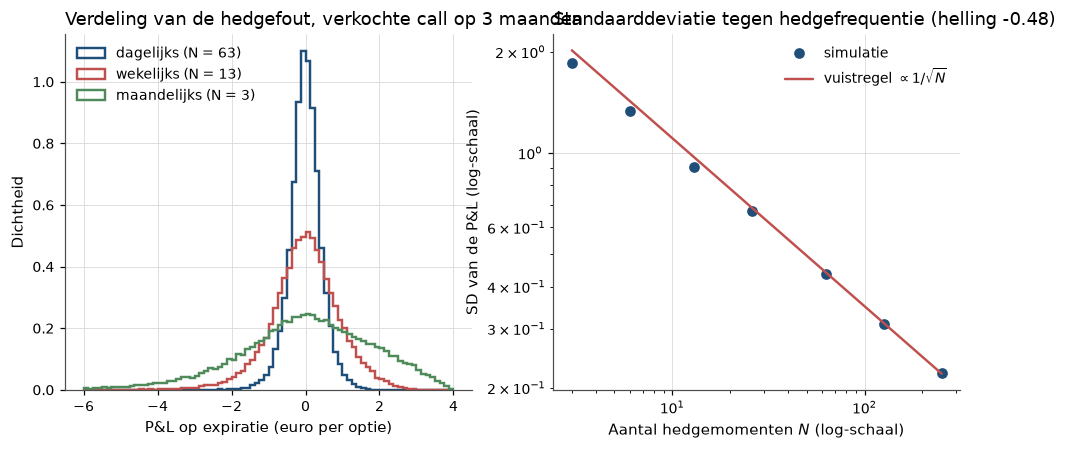

In [8]:
n_grid = np.array([3, 6, 13, 26, 63, 126, 252])
sd_grid = np.array([
    delta_hedge_pnl(n, 10_000, 100.0, 100.0, T_sim, r_sim, mu_sim, sigma_sim, sigma_sim).std(ddof=1)
    for n in n_grid
])
slope_sd = np.polyfit(np.log(n_grid), np.log(sd_grid), 1)[0]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
bins = np.linspace(-6, 4, 81)
for i, (name, pnl) in enumerate(pnl_by_freq.items()):
    axes[0].hist(pnl, bins=bins, density=True, histtype="step", lw=1.6,
                 color=hap.plotting.COLORS[i], label=f"{name} (N = {frequencies[name]})")
axes[0].set_title("Verdeling van de hedgefout, verkochte call op 3 maanden")
axes[0].set_xlabel("P&L op expiratie (euro per optie)")
axes[0].set_ylabel("Dichtheid")
axes[0].legend()

axes[1].loglog(n_grid, sd_grid, "o", color=hap.plotting.COLORS[0], label="simulatie")
axes[1].loglog(n_grid, np.sqrt(np.pi / 4) * vega_sim * sigma_sim / np.sqrt(n_grid),
               color=hap.plotting.COLORS[1], label=r"vuistregel $\propto 1/\sqrt{N}$")
axes[1].set_title(f"Standaarddeviatie tegen hedgefrequentie (helling {slope_sd:.2f})")
axes[1].set_xlabel("Aantal hedgemomenten $N$ (log-schaal)")
axes[1].set_ylabel("SD van de P&L (log-schaal)")
axes[1].legend()
plt.show()

:::{figure} #cel-black-scholes-hedgefout
:label: fig-black-scholes-hedgefout
:width: 95%

Links: de hedgefout is gemiddeld nul bij elke frequentie, maar bij maandelijks
hedgen is haar spreiding ruim veertig procent van de optiepremie. Rechts: over bijna
twee decaden in $N$ volgt de spreiding de $1/\sqrt{N}$-wet. De drift van 10% per
jaar is nergens terug te zien.
:::

De spreiding daalt van $1{,}86$ (maandelijks) via $0{,}92$ naar $0{,}43$ euro
(dagelijks), en over $N = 3$ tot $252$ is de log-log-helling $-0{,}48$. De
vuistregel overschat bij weinig hedgemomenten iets ($2{,}02$ tegen $1{,}86$), zoals
een benadering voor grote $N$ doet. De drift van 10% laat bij dagelijks hedgen een
gemiddelde van $-0{,}002$ na, met een standaardfout van $0{,}002$; bij maandelijks
hedgen $-0{,}019$ ($t \approx -2{,}3$), minder dan een half procent van de premie van
$4{,}49$. De staart is het echte risico: het 5%-kwantiel van de maandelijkse hedger
ligt op $-3{,}25$, bijna driekwart van de premie.

Hier keert motief 1 terug. Een handelaar die tien jaar lang elke maand één optie
verkoopt tegen één volatiliteitspunt te veel, verwacht per optie ongeveer de vega
maal $0{,}01$, dus $0{,}20$ euro. Hedget hij dagelijks, dan is de standaardfout van
zijn gemiddelde na 120 opties $0{,}43/\sqrt{120} = 0{,}04$: het voordeel is met
$t \approx 5$ zichtbaar. Hedget hij maandelijks, dan is die standaardfout
$1{,}86/\sqrt{120} = 0{,}17$ en is het voordeel na tien jaar niet van ruis te
onderscheiden. Een voordeel in *volatiliteit* is meetbaar op een manier waarop een
voordeel in *gemiddeld rendement* dat bijna nooit is — mits de hedgeruis klein
blijft, en in deze gestileerde wereld zonder onzekerheid over de volatiliteit zelf.

Tot slot de verkeerde $\sigma$: het aandeel beweegt met 20%, de handelaar verkoopt
tegen 15% of 25% en hedget dagelijks, óf met die implied volatility, óf met de
werkelijke 20%. [](#eq-black-scholes-hedge-pnl) voorspelt gemiddeld ongeveer
$\nu(\sigma_i - \sigma_r)$.

In [9]:
wrong_rows = []
for sigma_i in (0.15, 0.25):
    premium_gap = (bs_price(100.0, 100.0, T_sim, r_sim, sigma_i)
                   - bs_price(100.0, 100.0, T_sim, r_sim, sigma_sim)) * np.exp(r_sim * T_sim)
    for label, sigma_h in (("hedge bij implied", sigma_i), ("hedge bij werkelijke", sigma_sim)):
        pnl = delta_hedge_pnl(63, n_paths, 100.0, 100.0, T_sim, r_sim, mu_sim,
                              sigma_sim, sigma_i, sigma_hedge=sigma_h)
        wrong_rows.append({"sigma_i": sigma_i, "hedge": label, "gemiddelde P&L": pnl.mean(),
                           "SD P&L": pnl.std(ddof=1), "premieverschil": premium_gap,
                           "vega x (sigma_i - sigma_r)": vega_sim * (sigma_i - sigma_sim)})
pd.DataFrame(wrong_rows).set_index(["sigma_i", "hedge"]).round(4)

gemiddelde P&L  SD P&L  premieverschil  \
sigma_i hedge                                                          
0.15    hedge bij implied            -0.9838  0.6096         -0.9947   
        hedge bij werkelijke         -0.9955  0.4320         -0.9947   
0.25    hedge bij implied             0.9960  0.5478          0.9968   
        hedge bij werkelijke          0.9960  0.4297          0.9968   

                              vega x (sigma_i - sigma_r)  
sigma_i hedge                                             
0.15    hedge bij implied                        -0.9862  
        hedge bij werkelijke                     -0.9862  
0.25    hedge bij implied                         0.9862  
        hedge bij werkelijke                      0.9862

Wie tegen 15% verkoopt, verliest gemiddeld $0{,}98$ euro, wie tegen 25% verkoopt,
wint $1{,}00$, beide binnen enkele centen van het premieverschil en de
vega-benadering ($\mp 0{,}99$). Het verschil tussen de hedgekeuzes zit in de
spreiding. Wie met de werkelijke volatiliteit hedget, legt het premieverschil vast
met een spreiding van $0{,}43$ — alleen de discretisatiefout. Wie met de implied
volatility hedget, heeft $0{,}61$ (bij 15%) en $0{,}55$ (bij 25%): zijn winst hangt,
zoals de propositie zegt, af van waar de koers zich ophoudt.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Mark Rubinstein, *Implied Binomial Trees*, Journal of Finance 1994
{cite}`Rubinstein1994`; Derman en Kani, *The Volatility Smile and Its Implied Tree*,
1994 {cite}`DermanKani1994`.

**Wat.** Rubinsteins openingszin: "Despite its success, the Black-Scholes formula
has become increasingly unreliable over time in the very markets where one would
expect it to be most accurate" — de S&P 500-indexopties van de CBOE. Zijn
volledige tekst hebben wij niet kunnen inzien; Constantinides, Jackwerth en Perrakis
vatten zijn bevinding samen als: van april 1986 tot de crash van oktober 1987 is de
implied volatility "a moderately downward-sloping or u-shaped function of the
strike price", en "following the crash, the volatility smile is typically more
pronounced and downward sloping, often called a 'volatility skew'"
{cite}`ConstantinidesJackwerthPerrakis2008`. Derman en Kani: "ever since the '87
crash [...] out-of-the-money puts trade at higher implied volatilities than
out-of-the-money calls", met 47-daagse opties van 31 januari 1994 waarin de implied
volatility loopt van ongeveer 18% bij 90% van de spot tot ongeveer 8% bij 102%.

**Data hier.** Een momentopname van de volledige SPY-optieketen (28 expiraties,
van drie dagen tot ruim twee jaar), bied- en laatkoersen van het slot van de
voorgaande handelsdag, via `hap.data.yahoo_options("SPY", 28)`; de rente is
`hap.data.fred("DGS3MO")`, de termijnkoers volgt per expiratie uit pariteit.

**Verschil met het origineel.** Rubinstein had Europese SPX-opties en een tijdreeks
rond de crash; wij hebben één dag, bijna veertig jaar later, en SPY-opties zijn
Amerikaans en op een ETF met dividend. We gebruiken alleen out-of-the-money opties
en midkoersen. Het "vóór 1987"-deel kunnen we met gratis data niet repliceren.

**Verwachte afwijking.** De niveaus hangen van de dag af. Het *teken* moet identiek
zijn: voor elke expiratie tot één jaar ligt de implied volatility op 90% van de
termijnkoers boven die op de termijnkoers, en de helling is het steilst bij de
kortste looptijden. Is de kromme vlak of stijgend, dan klopt de code niet.
```

In [10]:
chain = hap_data.yahoo_options("SPY", 28)
spot = float(chain["spot"].iloc[0])
valuation = pd.Timestamp(chain.index.max().date()) + pd.Timedelta(hours=16)
r_cc = np.log1p(hap_data.fred("DGS3MO")["DGS3MO"].dropna().loc[:valuation].iloc[-1] / 100)

quotes = chain.reset_index()
quotes = quotes[(quotes["bid"] > 0) & (quotes["ask"] > quotes["bid"])].copy()
quotes["mid"] = 0.5 * (quotes["bid"] + quotes["ask"])
quotes["T"] = ((quotes["expiry"] + pd.Timedelta(hours=16) - valuation).dt.total_seconds()
               / (365.25 * 86400))
quotes = quotes[quotes["T"] > 2 / 365]
quotes["DF"] = np.exp(-r_cc * quotes["T"])


def parity_forward(group):
    """Median forward from put-call parity over strikes within 5% of spot."""
    wide = group.pivot_table(index="strike", columns="kind", values="mid").dropna()
    wide = wide[np.abs(np.log(wide.index / spot)) < 0.05]
    return float(np.median(wide.index + (wide["call"] - wide["put"]) / group["DF"].iloc[0]))


forwards = quotes.groupby("expiry").apply(parity_forward, include_groups=False).rename("F")
quotes = quotes.join(forwards, on="expiry")
otm = quotes[((quotes["kind"] == "put") & (quotes["strike"] < quotes["F"]))
             | ((quotes["kind"] == "call") & (quotes["strike"] >= quotes["F"]))].copy()
otm = otm[otm["mid"] >= 0.05]
otm["k"] = np.log(otm["strike"] / otm["F"])
# Black (1976): discounted forward as the underlying, so no dividend assumption is needed
otm["iv"] = implied_vol(otm["mid"].to_numpy(), (otm["DF"] * otm["F"]).to_numpy(),
                        otm["strike"].to_numpy(), otm["T"].to_numpy(), r_cc, otm["kind"].to_numpy())
otm = otm.dropna(subset=["iv"])
print(f"waarderingsmoment {valuation}, spot {spot:.2f}, r = {r_cc:.4f}, "
      f"{len(otm)} OTM-opties over {otm['expiry'].nunique()} expiraties")

waarderingsmoment 2026-09-11 16:00:00, spot 764.29, r = 0.0382, 4521 OTM-opties over 28 expiraties


In [11]:
def iv_at(group, k):
    """Linearly interpolated implied vol at log-moneyness k (NaN outside the quoted range)."""
    g = group.sort_values("k")
    return float(np.interp(k, g["k"], g["iv"])) if g["k"].min() <= k <= g["k"].max() else np.nan


smile_table = pd.DataFrame(
    {
        expiry: {
            "T (jaar)": g["T"].iloc[0],
            "F / spot - 1": g["F"].iloc[0] / spot - 1,
            "IV 90%": iv_at(g, np.log(0.90)),
            "IV 95%": iv_at(g, np.log(0.95)),
            "IV ATM": iv_at(g, 0.0),
            "IV 105%": iv_at(g, np.log(1.05)),
        }
        for expiry, g in otm.groupby("expiry")
    }
).T
smile_table["skew 90%-ATM"] = smile_table["IV 90%"] - smile_table["IV ATM"]
smile_table.index = smile_table.index.date
within_year = smile_table[smile_table["T (jaar)"] <= 1.0].dropna(subset=["skew 90%-ATM"])
print(f"expiraties tot 1 jaar met IV(90%) > IV(ATM): "
      f"{(within_year['skew 90%-ATM'] > 0).sum()} van {len(within_year)}")
smile_table.round(4)

expiraties tot 1 jaar met IV(90%) > IV(ATM): 19 van 19


,T (jaar),F / spot - 1,IV 90%,IV 95%,IV ATM,IV 105%,skew 90%-ATM
2026-09-14,0.0082,0.0002,NaN,0.2429,0.0708,NaN,NaN
2026-09-15,0.0110,0.0003,NaN,0.2271,0.0844,NaN,NaN
2026-09-16,0.0137,0.0003,NaN,0.2237,0.1076,NaN,NaN
2026-09-17,0.0164,0.0004,NaN,0.2206,0.1159,NaN,NaN
2026-09-18,0.0192,-0.0011,0.3420,0.2179,0.1261,NaN,0.2160
2026-09-25,0.0383,-0.0010,0.2709,0.1864,0.1183,0.1077,0.1525
2026-09-30,0.0520,-0.0006,0.2498,0.1794,0.1180,0.1002,0.1318
2026-10-02,0.0575,-0.0002,0.2482,0.1808,0.1222,0.1007,0.1260
2026-10-09,0.0767,0.0007,0.2359,0.1765,0.1243,0.1007,0.1115
2026-10-16,0.0958,0.0014,0.2290,0.1753,0.1276,0.1038,0.1014


Black-Scholes voorspelt één getal per rij; de tabel geeft er vier die dalen van links
naar rechts. Voor alle negentien expiraties tot één jaar met een genoteerde put op
90% ligt de implied volatility daar boven die op de termijnkoers, en op 105% overal
eronder: geen glimlach maar een scheve grimas. De helling is het steilst bij de
kortste looptijd — ruim 21 volatiliteitspunten tussen 90% en at-the-money bij een
week, 10 bij vijf weken, 3 bij een jaar, 1 bij ruim twee jaar — en het verschil maal
$\sqrt{T}$ ligt tussen twee weken en anderhalf jaar steeds rond $0{,}03$, een
regelmaat die we signaleren maar niet uitwerken.

De vergelijking met Derman en Kani is opvallend: onze expiratie op 49 dagen loopt
van $22{,}1\%$ bij 90% via $13{,}4\%$ op de termijnkoers naar $11{,}0\%$ bij 105%,
een helling van dezelfde orde als hun 18% naar 8% in 1994. Twee kanttekeningen. De
vier kortste expiraties hebben geen put op 90% en een onbetrouwbaar lage
at-the-money-volatiliteit (7 tot 12%), omdat onze looptijd in kalendertijd telt en
er een weekend in zit. En de premie voor vroege uitoefening van Amerikaanse puts
maakt ze in volatiliteitstermen iets duurder; dat die een helling van tien tot twintig
punten zou maken is onwaarschijnlijk, maar met deze data niet exact te scheiden.

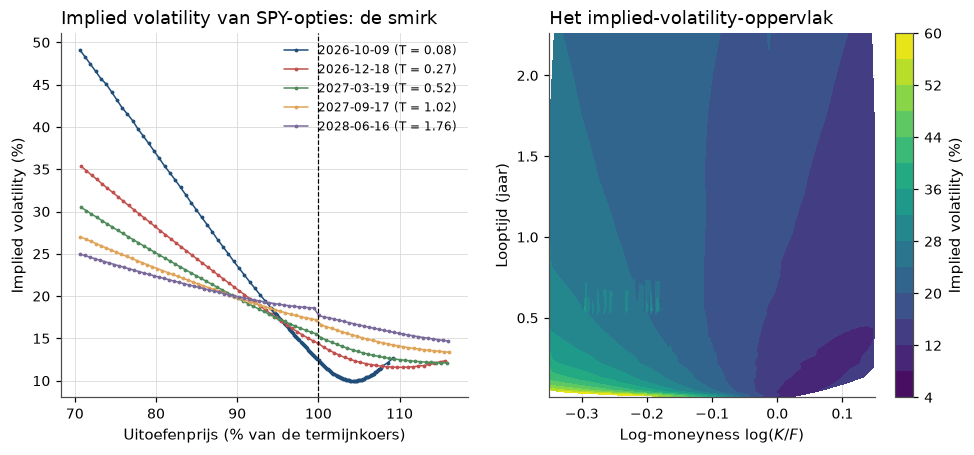

In [12]:
targets = [1 / 12, 0.25, 0.5, 1.0, 2.0]
expiry_T = otm.groupby("expiry")["T"].first()
chosen = [expiry_T.index[np.argmin(np.abs(expiry_T.to_numpy() - t))] for t in targets]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for i, expiry in enumerate(chosen):
    g = otm[(otm["expiry"] == expiry) & (otm["k"].between(-0.35, 0.15))].sort_values("k")
    axes[0].plot(np.exp(g["k"]) * 100, g["iv"] * 100, ".-", ms=3, lw=1.0,
                 color=hap.plotting.COLORS[i], label=f"{expiry.date()} (T = {g['T'].iloc[0]:.2f})")
axes[0].axvline(100, color="black", lw=0.8, ls="--")
axes[0].set_title("Implied volatility van SPY-opties: de smirk")
axes[0].set_xlabel("Uitoefenprijs (% van de termijnkoers)")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].legend(fontsize=8)

surface = otm[otm["k"].between(-0.35, 0.15) & (otm["T"] <= 2.5)]
contour = axes[1].tricontourf(surface["k"], surface["T"], surface["iv"] * 100, levels=14, cmap="viridis")
fig.colorbar(contour, ax=axes[1], label="Implied volatility (%)")
axes[1].set_title("Het implied-volatility-oppervlak")
axes[1].set_xlabel(r"Log-moneyness $\log(K/F)$")
axes[1].set_ylabel("Looptijd (jaar)")
plt.show()

:::{figure} #cel-black-scholes-smirk
:label: fig-black-scholes-smirk
:width: 95%

Links: onder Black-Scholes zou elke kromme een horizontale lijn op dezelfde hoogte
zijn. Alle krommen dalen — puts ver onder de termijnkoers zijn duur in
volatiliteitstermen — en het steilst bij de kortste looptijd. Rechts: hetzelfde als
oppervlak; de helling in de uitoefenprijs is overal aanwezig en vlakt af met de
looptijd.
:::

```{admonition} Replicatie
:class: seealso

**Bron.** Robert Whaley, *The Investor Fear Gauge*, Journal of Portfolio Management
2000 {cite}`Whaley2000`; Peter Carr en Liuren Wu, *Variance Risk Premiums*, Review
of Financial Studies 2009 {cite}`CarrWu2009`.

**Wat.** Het teken van de *variance risk premium* (het verschil tussen de in
optieprijzen ingeprijsde variantie en de daarna gerealiseerde variantie), die volgens
[](#eq-black-scholes-hedge-pnl) is wat een gehedgde optieverkoper verdient. Hun
tabellen hebben we niet ingezien en we noemen er geen getallen uit; de kwantitatieve
behandeling volgt in [](#05-29-opties-crashrisico).

**Data hier.** De VIX van FRED (`hap.data.fred("VIXCLS")`, vanaf 1990) en de
dagelijkse marktfactor van Kenneth French (`hap.data.market_daily()`), waaruit we per
dag de gerealiseerde volatiliteit over de volgende 21 handelsdagen berekenen.

**Verschil met het origineel.** De VIX meet de verwachte volatiliteit van de
S&P 500 over dertig kalenderdagen; wij vergelijken met de gerealiseerde volatiliteit
van de hele Amerikaanse markt over 21 handelsdagen (wortel van het gemiddelde
gekwadrateerde log-rendement, op jaarbasis).

**Verwachte afwijking.** Het verschil moet gemiddeld positief zijn, met een
Newey-West-$t$-waarde ruim boven twee, en op een ruime meerderheid van de dagen
positief; in crisismaanden zoals eind 2008 en begin 2020 moet het omslaan. Een
negatief gemiddelde betekent een fout in de code.
```

In [13]:
vix = (hap_data.fred("VIXCLS")["VIXCLS"].dropna() / 100).rename("VIX")
log_mkt = np.log1p(hap_data.market_daily()["Mkt"])
realized_fwd = np.sqrt(252 * log_mkt.pow(2).rolling(21).mean().shift(-21)).rename("RV volgende 21 dagen")

vrp = vix.to_frame().join(realized_fwd, how="inner").dropna()
vrp["verschil"] = vrp["VIX"] - vrp["RV volgende 21 dagen"]
nw = hap.newey_west(vrp["verschil"], pd.Series(1.0, index=vrp.index, name="const"),
                    lags=42, add_constant=False)
print(f"{vrp.index[0].date()} t/m {vrp.index[-1].date()}: {len(vrp)} handelsdagen")

pd.DataFrame(
    {
        "waarde": [
            vrp["VIX"].mean(), vrp["RV volgende 21 dagen"].mean(),
            vrp["verschil"].mean(), float(nw.bse.iloc[0]), float(nw.tvalues.iloc[0]),
            (vrp["verschil"] > 0).mean(),
            (vrp["VIX"] ** 2 - vrp["RV volgende 21 dagen"] ** 2).mean(),
        ]
    },
    index=["gemiddelde VIX", "gemiddelde RV",
           "gemiddeld verschil (vol)", "Newey-West SE", "Newey-West t",
           "fractie dagen VIX > RV", "gemiddeld verschil (variantie)"],
).round(4)

1990-01-02 t/m 2026-07-01: 9188 handelsdagen


,waarde
gemiddelde VIX,0.1945
gemiddelde RV,0.1546
gemiddeld verschil (vol),0.0399
Newey-West SE,0.0031
Newey-West t,12.8050
fractie dagen VIX > RV,0.8500
gemiddeld verschil (variantie),0.0110


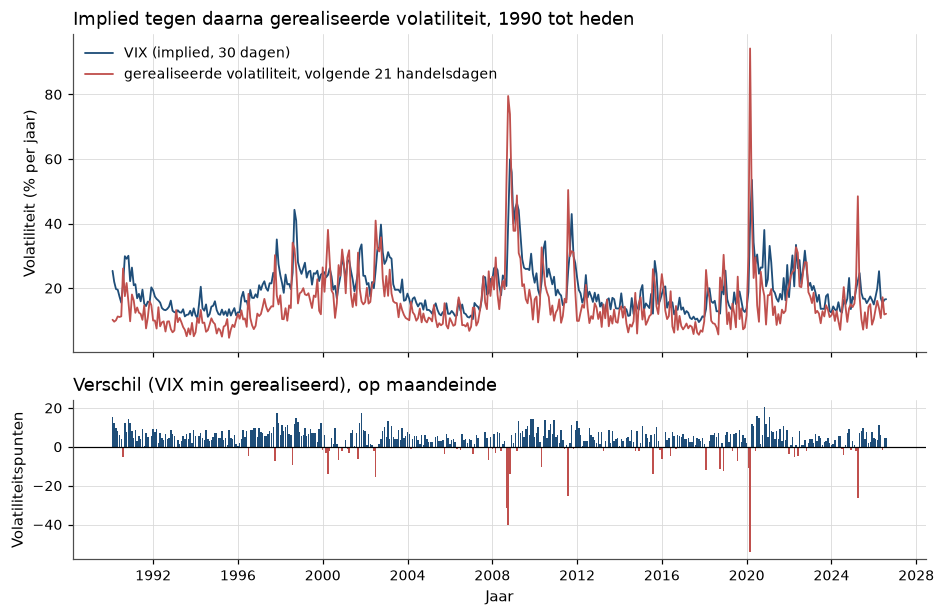

In [14]:
monthly_vrp = vrp.resample("ME").last()

fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True, height_ratios=[2, 1])
axes[0].plot(monthly_vrp.index, monthly_vrp["VIX"] * 100, lw=1.2, label="VIX (implied, 30 dagen)")
axes[0].plot(monthly_vrp.index, monthly_vrp["RV volgende 21 dagen"] * 100, lw=1.2,
             label="gerealiseerde volatiliteit, volgende 21 handelsdagen")
axes[0].set_title("Implied tegen daarna gerealiseerde volatiliteit, 1990 tot heden")
axes[0].set_ylabel("Volatiliteit (% per jaar)")
axes[0].legend()
axes[1].bar(monthly_vrp.index, monthly_vrp["verschil"] * 100, width=25,
            color=np.where(monthly_vrp["verschil"] > 0, hap.plotting.COLORS[0], hap.plotting.COLORS[1]))
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Verschil (VIX min gerealiseerd), op maandeinde")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("Volatiliteitspunten")
plt.show()

:::{figure} #cel-black-scholes-vrp
:label: fig-black-scholes-vrp
:width: 95%

De VIX ligt meestal boven de volatiliteit die daarna optreedt; opties zijn in die zin
gemiddeld duur. De rode staven zijn zeldzaam maar groot: wie opties verkoopt,
verdient in de meeste maanden een beetje en verliest in enkele maanden veel.
:::

Over 9188 handelsdagen van januari 1990 tot juli 2026 lag de VIX gemiddeld op
$19{,}5\%$ en de daarna gerealiseerde volatiliteit op $15{,}5\%$: een verschil van
$4{,}0$ volatiliteitspunten, met een Newey-West-standaardfout van $0{,}31$ en
$t = 12{,}8$, positief op 85% van de dagen. De grootste negatieve maanden vallen, zoals
verwacht, eind februari 2020 en augustus–september 2008, gevolgd door maart 2025 en
juli 2011.

Leg die $t$-waarde naast motief 1. Een equity premium van zes procent bij twintig
procent volatiliteit haalt over 36 jaar $t = 0{,}06\sqrt{36}/0{,}20 = 1{,}8$; de
variance risk premium haalt bijna dertien, omdat ze een verschil van tweede momenten
is. Wat ze *betekent*, is een andere zaak: de VIX en gerealiseerde volatiliteit
krijgen hun eigen lecture in [](#04-21-volatiliteit), en of de premie een beloning
voor crashrisico is of een te hoge prijs voor verzekering, is de vraag van
[](#05-29-opties-crashrisico).

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Het leverde de eerste prijs zonder voorkeuren: uit één
argument — wat zonder risico is, verdient de rente — volgt een formule met vier
waarneembare invoergrootheden en één te schatten getal, waarmee een nieuwe markt
zichzelf binnen enkele jaren prijsde. Het verklaart waarom Samuelsons $\alpha$ er
niet toe doet, waarom een optie meer waard is naarmate het aandeel wilder beweegt, en
waarom een Amerikaanse call zonder dividend nooit vroeg wordt uitgeoefend. De
simulatie liet zien hoe robuust de kern is: de drift verdwijnt uit de uitkomst en de
restfout volgt de $1/\sqrt{N}$-wet. En het reikte verder dan opties: de "corporate
liabilities" uit de titel zijn aandelen en obligaties als opties op de waarde van de
onderneming.

**Waar het breekt.** Het model voorspelt één volatiliteit per aandeel; de markt geeft
er een per uitoefenprijs en looptijd. Op onze handelsdag lag de implied volatility van
een put op 90% van de termijnkoers bij alle negentien expiraties tot een jaar boven
die op de termijnkoers, van ruim 21 volatiliteitspunten bij een week tot 3 bij een
jaar — de vorm die Rubinstein en Derman en Kani in 1994 zagen. Implied volatility
wordt zo van een parameter een *oppervlak*, en wat de meetlat meet, is een
risiconeutrale verdeling met een dikkere linkerstaart dan de lognormale. Dit is geen
schattingsprobleem: tweede momenten zijn goed meetbaar, en de variance risk premium
haalde $t = 12{,}8$ waar een equity premium op $1{,}8$ blijft steken.

**Risico of vergissing?** De Chicago-lezing: koersen maken sprongen en volatiliteit
stijgt als koersen dalen, dus een diepe put verzekert tegen de toestanden waarin een
euro het meest waard is. Zo'n risico is niet continu weg te hedgen — de markt is niet
compleet — en wie het draagt, eist een premie: in Santa-Clara's woorden "risk that
was priced". De Yale-lezing: sinds 1987 is er structurele vraag naar bescherming,
terwijl de schrijvers van puts beperkt kapitaal hebben en zich niet tegen een sprong
kunnen indekken; de prijs ligt dan boven wat een redelijk risicomodel rechtvaardigt.
Constantinides, Jackwerth en Perrakis vonden dat opties vóór de crash "reasonably
well" met Black-Scholes overeenkomen, maar dat er daarna, ook na transactiekosten,
strategieën bestaan die elke belegger met dalend marginaal nut zou verkiezen
{cite}`ConstantinidesJackwerthPerrakis2008`, en lezen dat als mispricing. Scheiden
vraagt de stochastic discount factor in crashtoestanden — en die komen in een eeuw
data te weinig voor. De data van deze lecture kiezen niet.

**Wat er daarna kwam.** Merton gebruikte dezelfde continue-tijdwiskunde om de
portefeuillekeuze van beleggers en het evenwicht van de hele markt opnieuw af te
leiden: zie [](#03-10-merton-icapm).

## Oefeningen

:::{exercise}
:label: ex-black-scholes-1

**De P&L van een gammapositie.**

1. Toon met [](#eq-black-scholes-pariteit) aan dat gamma en vega van call en put
   gelijk zijn. Waarom moet dat zo zijn, zonder te rekenen?
2. Een handelaar koopt een at-the-money call op drie maanden ($S = K = 100$,
   $r = 4\%$) tegen 20% implied volatility en hedget dagelijks, terwijl het aandeel
   met 25% beweegt. Benader zijn verwachte winst met
   [](#eq-black-scholes-hedge-pnl) door $S^2\Gamma$ op de beginwaarde vast te houden,
   en vergelijk met de vega-benadering en een simulatie.
:::

:::{solution} ex-black-scholes-1
:class: dropdown

**(1)** $P = C - S + Ke^{-r\tau}$, en $-S + Ke^{-r\tau}$ is lineair in $S$ en hangt
niet van $\sigma$ af; de tweede afgeleide naar $S$ en de afgeleide naar $\sigma$
zijn dus gelijk. Zonder rekenen: call min put is een termijncontract.

**(2)** Voor een gekochte optie keert het teken in [](#eq-black-scholes-hedge-pnl) om.

In [15]:
g0 = bs_greeks(100.0, 100.0, 0.25, 0.04, 0.20)
approx = 0.5 * (0.25**2 - 0.20**2) * 100.0**2 * g0["gamma"] * 0.25
long_pnl = -delta_hedge_pnl(63, 50_000, 100.0, 100.0, 0.25, 0.04, 0.04, 0.25, 0.20)
print(f"benadering met vaste S^2 Gamma : {approx:.3f}")
print(f"vega x (0.25 - 0.20)           : {g0['vega'] * 0.05:.3f}")
print(f"simulatie, dagelijks hedgen    : {long_pnl.mean():.3f} (SE {long_pnl.std(ddof=1) / np.sqrt(50_000):.3f})")

benadering met vaste S^2 Gamma : 1.109
vega x (0.25 - 0.20)           : 0.986
simulatie, dagelijks hedgen    : 0.996 (SE 0.003)


De vaste-gamma-benadering ($1{,}11$) overschat de simulatie ($1{,}00$), omdat gamma
van een at-the-money optie maximaal is en daalt zodra de koers wegloopt; de
vega-benadering ($0{,}99$) middelt dat over de looptijd. Een gehedgde optie is een
weddenschap op gerealiseerde variantie waarvan de inzet afhangt van waar de koers
zich ophoudt.
:::

:::{exercise}
:label: ex-black-scholes-2

**Van de boom naar de formule.** Veralgemeen het toy-voorbeeld tot $n$ stappen over
$T = 0{,}25$ met $u = e^{\sigma\sqrt{T/n}}$, $d = 1/u$ en $R^{f} = e^{rT/n}$, bij
$S = K = 100$, $r = 4\%$ en $\sigma = 20\%$. Teken het verschil met
[](#eq-black-scholes-call) voor $n = 1, \dots, 200$. Hoe snel convergeert het, en
waarom oscilleert het?
:::

:::{solution} ex-black-scholes-2
:class: dropdown

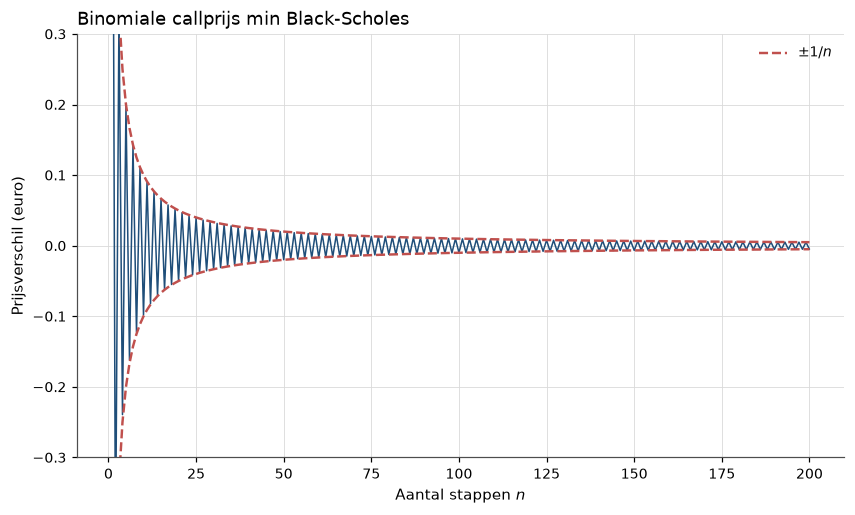

fout bij n = 3: 0.3328; n = 50: -0.0199; n = 200: -0.00498


In [16]:
def crr_call(S, K, T, r, sigma, n):
    """Cox-Ross-Rubinstein binomial price of a European call."""
    dt = T / n
    up = np.exp(sigma * np.sqrt(dt))
    q = (np.exp(r * dt) - 1 / up) / (up - 1 / up)
    j = np.arange(n + 1)
    terminal = np.maximum(S * up ** (2 * j - n) - K, 0.0)
    return np.exp(-r * T) * stats.binom.pmf(j, n, q) @ terminal


n_steps = np.arange(1, 201)
bs_exact = bs_price(100.0, 100.0, 0.25, 0.04, 0.20)
errors = np.array([crr_call(100.0, 100.0, 0.25, 0.04, 0.20, n) - bs_exact for n in n_steps])

fig, ax = plt.subplots()
ax.plot(n_steps, errors, lw=1.0)
ax.plot(n_steps, 1.0 / n_steps, color=hap.plotting.COLORS[1], ls="--", label=r"$\pm 1/n$")
ax.plot(n_steps, -1.0 / n_steps, color=hap.plotting.COLORS[1], ls="--")
ax.set_ylim(-0.3, 0.3)
ax.set_title("Binomiale callprijs min Black-Scholes")
ax.set_xlabel("Aantal stappen $n$")
ax.set_ylabel("Prijsverschil (euro)")
ax.legend()
plt.show()
print(f"fout bij n = 3: {errors[2]:.4f}; n = 50: {errors[49]:.4f}; n = 200: {errors[199]:.5f}")

De fout daalt ongeveer als $1/n$ en wisselt van teken, omdat de uitoefenprijs bij even
en oneven $n$ afwisselend op en tussen eindknopen valt: $0{,}33$ bij drie stappen,
een halve cent bij tweehonderd. De boom is dus geen benadering van een ander idee,
maar hetzelfde idee — replicatie per knoop — met de formule als limiet; de details
volgen in [](#03-11-apt-no-arbitrage).
:::

:::{exercise}
:label: ex-black-scholes-3

**Is de variance risk premium stabiel?** Splits de steekproef in 1990–2007 en
2008–heden. Bereken per periode het gemiddelde verschil tussen VIX en gerealiseerde
volatiliteit met een Newey-West-standaardfout, en met niet-overlappende maanddata
het aantal jaren $T^{*} = (1{,}96\,\SD/\text{gemiddelde})^2$ dat nodig is voor
significantie. Vergelijk met een equity premium van 6% bij 20% volatiliteit.
:::

:::{solution} ex-black-scholes-3
:class: dropdown

In [17]:
periods = {"1990-2007": vrp.loc[:"2007"], "2008-heden": vrp.loc["2008":]}
rows = []
for name, sample in periods.items():
    fit = hap.newey_west(sample["verschil"], pd.Series(1.0, index=sample.index, name="const"),
                         lags=42, add_constant=False)
    monthly = sample["verschil"].resample("ME").last().dropna()
    rows.append({
        "periode": name,
        "gemiddeld verschil": sample["verschil"].mean(),
        "NW SE": float(fit.bse.iloc[0]),
        "NW t": float(fit.tvalues.iloc[0]),
        "maanden": len(monthly),
        "jaren nodig (maanddata)": (1.96 * monthly.std(ddof=1) / monthly.mean()) ** 2 / 12,
    })
equity_years = (1.96 * 0.20 / 0.06) ** 2
print(f"jaren nodig voor een equity premium van 6% bij sigma = 20%: {equity_years:.1f}")
pd.DataFrame(rows).set_index("periode").round(4)

jaren nodig voor een equity premium van 6% bij sigma = 20%: 42.7


,gemiddeld verschil,NW SE,NW t,maanden,jaren nodig (maanddata)
periode,,,,,
1990-2007,0.0485,0.0032,15.0269,216,0.3297
2008-heden,0.0315,0.0052,6.1048,223,2.0260


Het verschil is in beide periodes positief en scherp gemeten: $4{,}85$ punten over
1990–2007 ($t = 15{,}0$) en $3{,}15$ punten vanaf 2008 ($t = 6{,}1$). Met maanddata is
voor significantie een derde jaar respectievelijk twee jaar nodig; voor de equity
premium 43 jaar — motief 1 in één regel. De kleinere premie na 2008 past bij beide
lezingen: arbitrageurs die een bekende vergissing wegnemen, of een crashrisico dat
blijft bestaan en dus beloond blijft.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->